## Installation

In [ ]:
!pip install numpy pandas matplotlib scikit-learn

## 1. Importing

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier

from scipy.spatial.distance import pdist, squareform

## 2. Load Dataset

In [9]:
points = {
    "Point": ["A", "B", "C", "D", "E"],
    "x": [1, 2, 4, 5, 8],
    "y": [1, 1, 3, 4, 8]
}

df = pd.DataFrame(points)

In [10]:
df.head()

,Point,x,y
0,A,1,1
1,B,2,1
2,C,4,3
3,D,5,4
4,E,8,8


## 3. Extract Features

In [11]:
X = df[["x", "y"]].values

In [12]:
X

array([[1, 1],
       [2, 1],
       [4, 3],
       [5, 4],
       [8, 8]])

In [35]:
dist_matrix = squareform(pdist(X, metric='euclidean'))
distance_df = pd.DataFrame(
    dist_matrix,
    index=df['Point'],
    columns=df['Point']
)
distance_df = distance_df.round(2)
distance_df

Point,A,B,C,D,E
Point,,,,,
A,0.00,1.00,3.61,5.00,9.90
B,1.00,0.00,2.83,4.24,9.22
C,3.61,2.83,0.00,1.41,6.40
D,5.00,4.24,1.41,0.00,5.00
E,9.90,9.22,6.40,5.00,0.00


## 4. Preprocess Data (Scaling)

- Hierarchical clustering is distance-based, so scaling helps.
- StandardScaler transforms data so that the mean becomes 0 and the standard deviation becomes 1.

In [ ]:
# For theoratical simulation, keep it as comment
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

In [ ]:
# X_scaled

## 5. Split the Data into Training and Test Sets

**Clustering is an unsupervised learning technique, so it usually does not require a train/test split.**

In supervised learning, datasets are divided into training and testing sets because the model learns from labeled data and must be evaluated on unseen examples to measure prediction accuracy. The test set helps determine how well the model generalizes to new data.

Clustering works differently. In clustering algorithms such as K-Means, Hierarchical Clustering, or DBSCAN, there are **no target labels (`y`)** provided. The algorithm tries to discover hidden patterns, structures, or natural groupings within the dataset based only on feature similarity.

Because there is no “correct answer” to predict:

* The model is not trained to map inputs to known outputs.
* There is no classification accuracy or prediction error to evaluate on a separate test set.
* The main objective is exploratory analysis and pattern discovery rather than prediction.

Therefore, clustering is generally performed on the **entire dataset** to allow the algorithm to identify the most meaningful cluster structure from all available information.

## 6. Define the Model (Linkage Matrix)

`linkage()` computes distances internally, but it does NOT return a distance matrix.

Each row looks like:
```
[cluster1, cluster2, distance, sample_count]
```
Example:

```
[0, 1, 0.12, 2]
```
Meaning:

- cluster `0` and `1` merged
- at distance 0.12
- forming a cluster of size 2

### How to identify which cluster is which (in linkage output)
In the linkage matrix (`Z`), clusters are represented using IDs, but they are not always original points.

When clustering begins:

Rule:
- IDs `0` to `n-1` → original points
- IDs `n` and above → newly formed clusters

So if `n` = `5`:

- 0–4 → original points
- 5 → first merged cluster
- 6 → second merged cluster
- etc.

In [19]:
single_linked = linkage(X, method='single')
complete_linked = linkage(X, method='complete')
ward_linked = linkage(X, method='ward')

In [20]:
single_linked

array([[0.        , 1.        , 1.        , 2.        ],
       [2.        , 3.        , 1.41421356, 2.        ],
       [5.        , 6.        , 2.82842712, 4.        ],
       [4.        , 7.        , 5.        , 5.        ]])

In [21]:
complete_linked

array([[0.        , 1.        , 1.        , 2.        ],
       [2.        , 3.        , 1.41421356, 2.        ],
       [5.        , 6.        , 5.        , 4.        ],
       [4.        , 7.        , 9.89949494, 5.        ]])

In [22]:
ward_linked

array([[0.        , 1.        , 1.        , 2.        ],
       [2.        , 3.        , 1.41421356, 2.        ],
       [5.        , 6.        , 5.52268051, 4.        ],
       [4.        , 7.        , 9.63846461, 5.        ]])

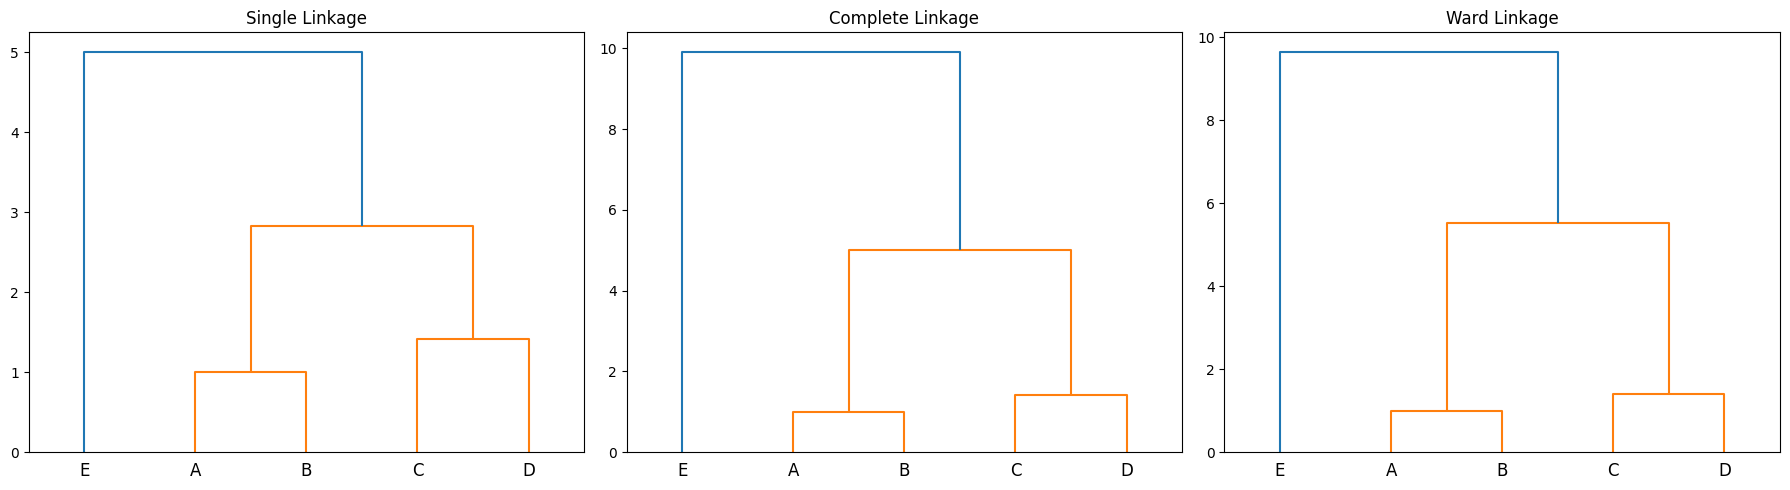

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Single linkage dendrogram
dendrogram(single_linked, ax=axes[0], labels=df["Point"].values)
axes[0].set_title("Single Linkage")

# Complete linkage dendrogram
dendrogram(complete_linked, ax=axes[1], labels=df["Point"].values)
axes[1].set_title("Complete Linkage")

# Ward linkage dendrogram
dendrogram(ward_linked, ax=axes[2], labels=df["Point"].values)
axes[2].set_title("Ward Linkage")

plt.tight_layout()
plt.show()

## 7. Train the Model

**Clustering algorithms do not require “training” in the same way as supervised learning models.**

In supervised learning, training means teaching a model using labeled examples so it can learn the relationship between input features (`X`) and target outputs (`y`). The model adjusts its parameters over many iterations to minimize prediction error.

Clustering is different because it is an **unsupervised learning method**:

* There are no predefined labels or target values.
* The algorithm is not learning from correct answers.
* Instead, it automatically groups similar data points based on distance, similarity, or density.

For example:

* **K-Means** repeatedly updates cluster centroids until groups stabilize.
* **Hierarchical Clustering** builds clusters by merging or splitting data points based on similarity.
* **DBSCAN** forms clusters using density relationships among points.

These processes are considered **fitting** or **applying** the algorithm rather than traditional model training.

Therefore:

* Clustering does not need a separate “training phase” with labeled data.
* The algorithm directly analyzes the dataset to discover hidden patterns and structures.
* The output is a set of clusters rather than predictions of known classes.

In practice, we often say the clustering model is “fit” to the data, but this differs from supervised model training because no target labels are used.

### 7.1 Form Clusters (No Training Needed)

We cut the dendrogram to form clusters.

**`fcluster`** is used to extract flat clusters from a hierarchical clustering result by “cutting” the dendrogram at a chosen level.

Unlike supervised learning models, there is no training process here. `fcluster` simply interprets the already-built linkage tree and assigns cluster labels based on a stopping rule.

For example:

* You can specify the number of clusters using `criterion='maxclust'`
* Or define a distance threshold using `criterion='distance'`

When you use:

```python
fcluster(linkage_matrix, t=2, criterion='maxclust')
```

it means: “Split the dendrogram into exactly 2 clusters”

Each data point is assigned a cluster label based on which branch of the dendrogram it belongs to at that cut level.

So, `fcluster` is not training anything—it is just **decoding the hierarchical structure into final cluster labels**.

**Differences between `AgglomerativeClustering` and `fcluster`**

| Feature                  | AgglomerativeClustering        | fcluster                         |
| ------------------------ | ------------------------------ | -------------------------------- |
| Library                  | sklearn                        | scipy                            |
| Purpose                  | Build + cut hierarchy directly | Cut an existing linkage tree     |
| Input                    | Raw data `X`                   | Linkage matrix `Z`               |
| Produces dendrogram info | Limited                        | Full hierarchy                   |
| `.fit()` API             | Yes                            | No                               |
| Predict labels           | Yes (`fit_predict`)            | Yes (cluster labels from tree)   |
| Best for ML workflows    | Yes                            | More scientific/control-oriented |


In [26]:
single_clusters = fcluster(single_linked, t=2, criterion='maxclust')
complete_clusters = fcluster(complete_linked, t=2, criterion='maxclust')
ward_clusters = fcluster(ward_linked, t=2, criterion='maxclust')
df['Signle'] = single_clusters
df['Complete'] = complete_clusters
df['Ward'] = ward_clusters

In [27]:
df

,Point,x,y,Signle,Complete,Ward
0,A,1,1,1,1,1
1,B,2,1,1,1,1
2,C,4,3,1,1,1
3,D,5,4,1,1,1
4,E,8,8,2,2,2


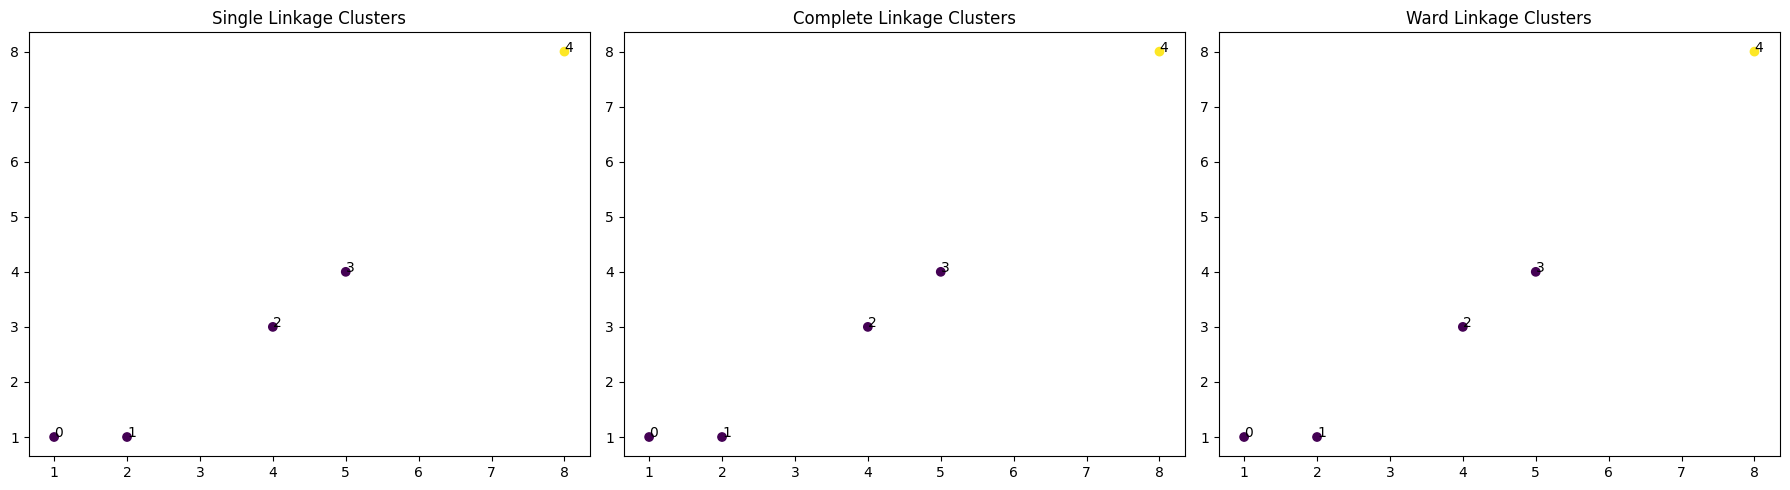

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Single linkage clusters
axes[0].scatter(X[:, 0], X[:, 1], c=single_clusters)
axes[0].set_title("Single Linkage Clusters")

for i, txt in enumerate(df.index):
    axes[0].annotate(txt, (X[i, 0], X[i, 1]))

# Complete linkage clusters
axes[1].scatter(X[:, 0], X[:, 1], c=complete_clusters)
axes[1].set_title("Complete Linkage Clusters")

for i, txt in enumerate(df.index):
    axes[1].annotate(txt, (X[i, 0], X[i, 1]))

# Ward linkage clusters
axes[2].scatter(X[:, 0], X[:, 1], c=ward_clusters)
axes[2].set_title("Ward Linkage Clusters")

for i, txt in enumerate(df.index):
    axes[2].annotate(txt, (X[i, 0], X[i, 1]))

plt.tight_layout()
plt.show()

## 8. Make Predictions

Hierarchical clustering is descriptive, not predictive. It describes relationships among existing data. It does not generalize to unseen data automatically. It is **not a learned function**, it is a **structure built on the full dataset**:

* It starts with all data points and repeatedly merges (or splits) them based on distance.
* The result is a **tree structure (dendrogram)** that describes relationships *only among the training data points*.
* There are **no learned parameters** like weights (in regression) or centroids (in K-Means).
* So there is no built-in rule like:
  *“Given a new point, compute output cluster directly.”*

In short, Itt organizes existing data, not a model that generalizes to unseen samples.


If a new data point arrives:

* It was never part of the original hierarchy.
* The dendrogram does not define how to insert it.
* Rebuilding the whole hierarchy every time is expensive and inconsistent.

So hierarchical clustering is **not naturally scalable for prediction tasks**.


To predict cluster membership for new data points, additional methods are needed because hierarchical clustering does not create a direct prediction function like supervised learning models.

For new observations:

* The new data must first be preprocessed in the same way as the original dataset (such as scaling or normalization).
* Then, similarity or distance between the new point and existing clusters is measured.
* The new point can be assigned to the nearest cluster based on distance metrics or centroid-like representations.

Unlike classification algorithms:

* Hierarchical clustering does not “learn” labeled patterns.
* It mainly builds a hierarchy of relationships among the current dataset.
* Therefore, predictions for unseen data are indirect and less straightforward.

**How we solve this issue**

There are a few practical approaches:

1. Assign to nearest cluster (most common solution)

    After forming clusters, you:

    * Compute a representative point for each cluster (e.g., centroid or medoid)
    * Assign a new point to the closest cluster using distance (e.g., Euclidean distance)

    This turns clustering into a **pseudo-predictive system**.

2. Use cluster centroids like K-Means

    Even though hierarchical clustering doesn’t define centroids, we can:

    * Compute the mean of each cluster
    * Treat them like K-Means centroids
    * Assign new points based on nearest centroid

    This is the most practical workaround in production.

3. Refit the model with new data

    * Add new data to dataset
    * Re-run hierarchical clustering
    * Rebuild dendrogram

    This ensures correctness but is:

    * computationally expensive
    * not scalable for large or streaming data

4. Use alternative models for prediction

    If prediction is important, switch to:

    * **K-Means** (easier assignment to new points)
    * **Gaussian Mixture Models**
    * **DBSCAN + nearest cluster assignment**
    * or supervised models if labels exist

In [32]:
# New point to predict
new_point = np.array([[3, 2]])

# Scale new point
# new_point_scaled = scaler.transform(new_point)

# SINGLE linkage predictor
single_knn = KNeighborsClassifier(n_neighbors=1)
single_knn.fit(X, single_clusters)

# COMPLETE linkage predictor
complete_knn = KNeighborsClassifier(n_neighbors=1)
complete_knn.fit(X, complete_clusters)

# WARD linkage predictor
ward_knn = KNeighborsClassifier(n_neighbors=1)
ward_knn.fit(X, ward_clusters)

# Predictions
single_pred = single_knn.predict(new_point)
complete_pred = complete_knn.predict(new_point)
ward_pred = ward_knn.predict(new_point)

print("Single Linkage Cluster :", single_pred[0])
print("Complete Linkage Cluster :", complete_pred[0])
print("Ward Linkage Cluster :", ward_pred[0])

Single Linkage Cluster : 1
Complete Linkage Cluster : 1
Ward Linkage Cluster : 1


## 9. Evaluate Model

Since clustering is unsupervised, we use Silhouette Score.

In [33]:
singl_score = silhouette_score(X, single_clusters)
complete_score = silhouette_score(X, complete_clusters)
ward_score = silhouette_score(X, ward_clusters)

In [34]:
print("Single Linkage Silhouette Score :", singl_score)
print("Complete Linkage Silhouette Score:", complete_score)
print("Ward Linkage Silhouette Score   :", ward_score)

Single Linkage Silhouette Score : 0.4531473375500402
Complete Linkage Silhouette Score: 0.4531473375500402
Ward Linkage Silhouette Score   : 0.4531473375500402
